# Pyvale example: Sensor model & `get_measurements()` vs `calc_measurements()`
In this example we explain the pyvale virtual sensor measurement model. For a
virtual sensor in pyvale a measurement is defined as measurement = truth +
systematic error + random error. Sources of systematic errors include: spatial/
temporal averaging, uncertainty in position / sampling time / orientation,
digitisation, saturation, and calibration. Sources of random error are generally
due to measurement noise characterised by a given probability distribution.

Random errors can be mitigated by performing multiple experiments and averaging.
However, systematic errors cannot easily be accounted for without a forward
model of the source of the error. Characterising the contribution of systematic
errors to the total measurement error is a key application of `pyvale`.

A sensor array has two key methods: `get_measurements()` and `calc_measurements`
. Calling `get_measurements()` retrieves the results for the current simulated
experiment whereas calling `calc_measurements()` will generate a new simulated
experiment by sampling / calculating the systematic and random errors.

**Test case**: Scalar field point sensors (thermocouples) on a 2D thermal simulation

In [8]:
import matplotlib.pyplot as plt
import mooseherder as mh
import pyvale as pyv

The first part of this example is the similar to basics example 1.1, so
feel free to skip to after the first call to `calc_measurements()`.

Here we load a pre-generated MOOSE finite element simulation dataset that
comes packaged with pyvale. The simulation is a 2D rectangular plate with
a bi-directional temperature gradient. Then we scale to mm to make 3D visualisation scaling easier as pyvista scales everything to unity.

In [9]:
data_path = pyv.DataSet.thermal_2d_path()
sim_data = mh.ExodusReader(data_path).read_all_sim_data()
field_key: str = "temperature"
sim_data = pyv.scale_length_units(scale=1000.0,
                                    sim_data=sim_data,
                                    disp_comps=None)

We now use a helper function to create a grid of sensor locations but we
could have also manually built the numpy array of sensor locations which
has the shape=(num_sensors,coord[x,y,z]).

In [10]:
n_sens = (4,1,1)
x_lims = (0.0,100.0)
y_lims = (0.0,50.0)
z_lims = (0.0,0.0)
sens_pos = pyv.create_sensor_pos_array(n_sens,x_lims,y_lims,z_lims)

This dataclass contains the parameters to build our sensor array. We can
also customise the output frequency, the sensor area and the sensor
orientation. For now we will use the defaults which assumes an ideal point
sensor sampling at the simulation time steps.

In [11]:
sens_data = pyv.SensorData(positions=sens_pos)

Now that we have our sensor locations we can use the sensor factory to
build a basic thermocouple array with some useful defaults. In later
examples we will see how to customise sensor parameters and errors.
This basic thermocouple array includes a 5% systematic and random error -
We are specifically using exaggerated errors here for visualisation.

In [12]:
tc_array = pyv.SensorArrayFactory \
    .thermocouples_basic_errs(sim_data,
                                sens_data,
                                elem_dims=2,
                                field_name=field_key,
                                errs_pc=5.0)

We have built our sensor array so now we can call `calc_measurements()` to
generate simulated sensor traces.

In [13]:
measurements = tc_array.calc_measurements()

From here we are going to experiment with repeated calls to
`calc_measurements()` and `get_measurements()` for our sensor array. We
will print the results to the console as well as plotting time traces of
the simulated sensor output. All further explanations are in the print
statements below.

In [14]:
print("\n"+80*"-")
print("For a sensor array: "
        + "measurement = truth + sysematic error + random error")
print(f"\nmeasurements.shape = {measurements.shape} = "
        + "(n_sensors,n_field_components,n_timesteps)\n")
print("Here we have a scalar temperature field so only 1 field component.")
print("The truth, systematic error and random error arrays all have the "+
        "same shape.")

sens_print: int = 0
time_print: int = 5
comp_print: int = 0

print(80*"-")
print(f"Looking at the last {time_print} virtual measurements" +
        f" of sensor {sens_print}:")

pyv.print_measurements(sens_array=tc_array,
                        sensors=(sens_print,sens_print+1),
                        components=(comp_print,comp_print+1),
                        time_steps=(measurements.shape[2]-time_print,
                                    measurements.shape[2]))
print(80*"-")


--------------------------------------------------------------------------------
For a sensor array: measurement = truth + sysematic error + random error

measurements.shape = (4, 1, 41) = (n_sensors,n_field_components,n_timesteps)

Here we have a scalar temperature field so only 1 field component.
The truth, systematic error and random error arrays all have the same shape.
--------------------------------------------------------------------------------
Looking at the last 5 virtual measurements of sensor 0:

measurement.shape = 
    (4, 1, 41)
measurement = 
    [[[39.26086426 41.61071777 39.13879395 40.66467285 39.0625    ]]]
truth = 
    [[[38.83565155 38.83565196 38.83565221 38.83565238 38.83565248]]]
random errors = 
    [[[-0.5593299   1.79600764 -0.67921173  0.83846076 -0.7499406 ]]]
systematic errors = 
    [[[0.98454261 0.97905817 0.98235346 0.99055971 0.97678812]]]
total errors = 
    [[[0.42521271 2.77506582 0.30314173 1.82902048 0.22684752]]]

-----------------------------

--------------------------------------------------------------------------------
If we call the `calc_measurements()` method then the errors are re-calculated.

measurement.shape = 
    (4, 1, 41)
measurement = 
    [[[35.76660156 38.80310059 41.32080078 39.07775879 36.60583496]]]
truth = 
    [[[38.83565155 38.83565196 38.83565221 38.83565238 38.83565248]]]
random errors = 
    [[[-3.9186236   1.46902869  1.52000039  0.79087648 -3.26824265]]]
systematic errors = 
    [[[1.27478633 1.27348576 1.26828991 1.28025041 1.26527265]]]
total errors = 
    [[[-3.06904998 -0.03255137  2.48514857  0.24210641 -2.22981752]]]

--------------------------------------------------------------------------------


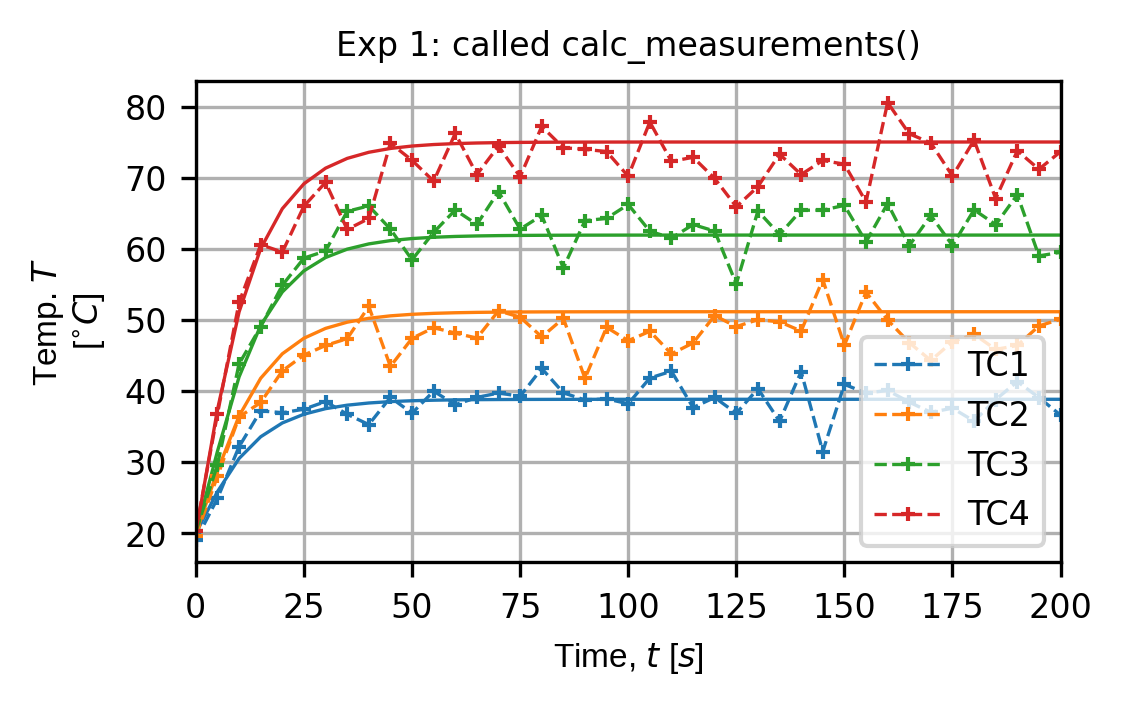

In [15]:
print(80*"-")
print("If we call the `calc_measurements()` method then the errors are "
        + "re-calculated.")
measurements = tc_array.calc_measurements()

pyv.print_measurements(sens_array=tc_array,
                        sensors=(sens_print,sens_print+1),
                        components=(comp_print,comp_print+1),
                        time_steps=(measurements.shape[2]-time_print,
                                    measurements.shape[2]))

(fig,ax) = pyv.plot_time_traces(tc_array,field_key)
ax.set_title("Exp 1: called calc_measurements()")

print(80*"-")

--------------------------------------------------------------------------------
If we call the `get_measurements()` method then the errors are the same:

measurement.shape = 
    (4, 1, 41)
measurement = 
    [[[35.76660156 38.80310059 41.32080078 39.07775879 36.60583496]]]
truth = 
    [[[38.83565155 38.83565196 38.83565221 38.83565238 38.83565248]]]
random errors = 
    [[[-3.9186236   1.46902869  1.52000039  0.79087648 -3.26824265]]]
systematic errors = 
    [[[1.27478633 1.27348576 1.26828991 1.28025041 1.26527265]]]
total errors = 
    [[[-3.06904998 -0.03255137  2.48514857  0.24210641 -2.22981752]]]

--------------------------------------------------------------------------------


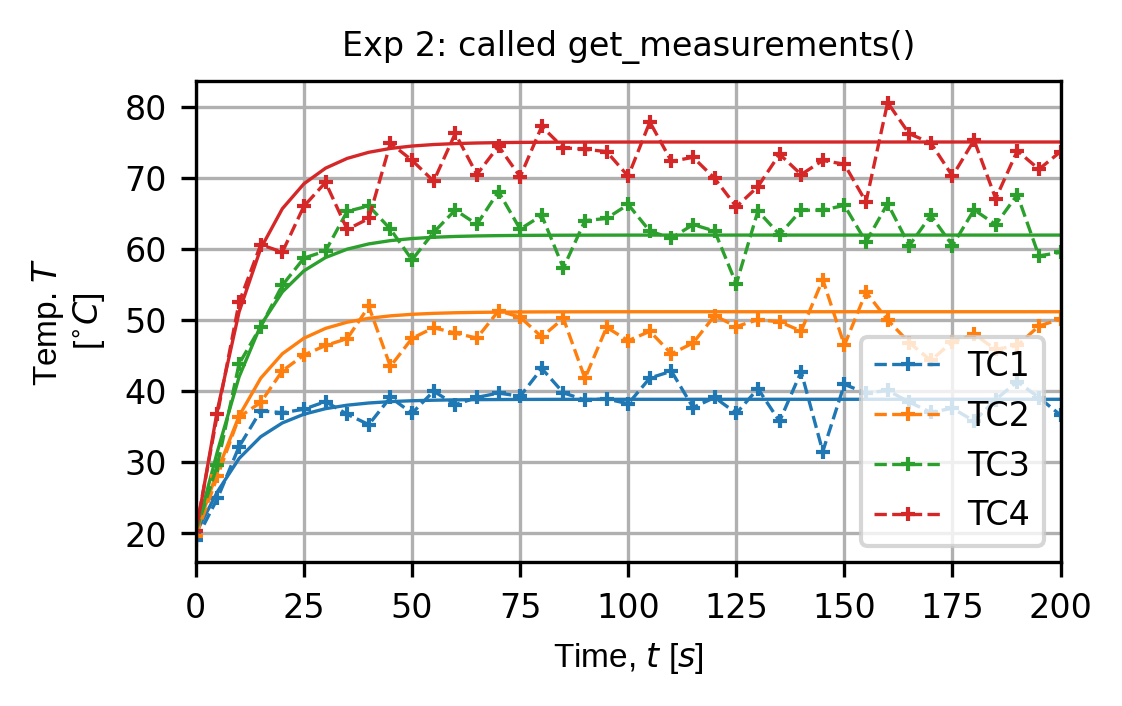

In [16]:
print(80*"-")
print("If we call the `get_measurements()` method then the errors are the "
        + "same:")
measurements = tc_array.get_measurements()

pyv.print_measurements(sens_array=tc_array,
                        sensors=(sens_print,sens_print+1),
                        components=(comp_print,comp_print+1),
                        time_steps=(measurements.shape[2]-time_print,
                                    measurements.shape[2]))

(fig,ax) = pyv.plot_time_traces(tc_array,field_key)
ax.set_title("Exp 2: called get_measurements()")

print(80*"-")

--------------------------------------------------------------------------------
If we call the `calc_measurements()` method again we generate / sample new errors:

measurement.shape = 
    (4, 1, 41)
measurement = 
    [[[40.25268555 37.8112793  38.45214844 37.55187988 37.78076172]]]
truth = 
    [[[38.83565155 38.83565196 38.83565221 38.83565238 38.83565248]]]
random errors = 
    [[[-1.43215031  1.51005648  2.20723581  0.58109662 -3.25455341]]]
systematic errors = 
    [[[0.20534704 0.2080853  0.19755071 0.20625778 0.19669266]]]
total errors = 
    [[[ 1.417034   -1.02437266 -0.38350378 -1.28377249 -1.05489076]]]

--------------------------------------------------------------------------------


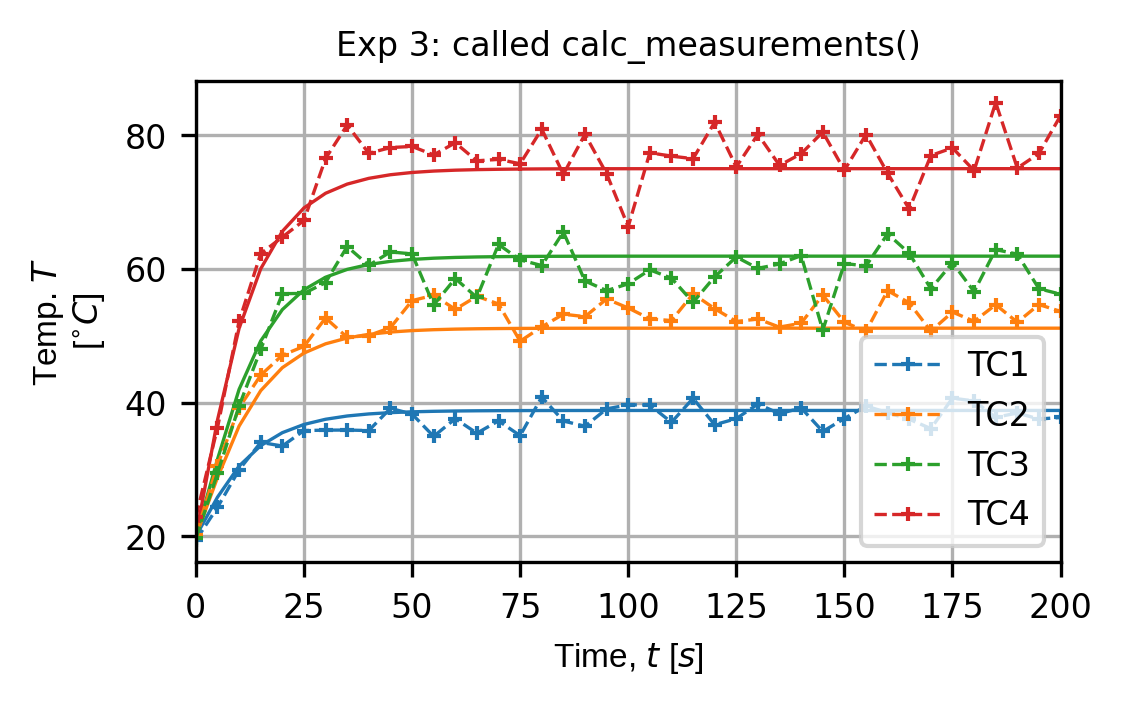

In [17]:
print(80*"-")
print("If we call the `calc_measurements()` method again we generate / "
        "sample new errors:")
measurements = tc_array.calc_measurements()

pyv.print_measurements(sens_array=tc_array,
                        sensors=(sens_print,sens_print+1),
                        components=(comp_print,comp_print+1),
                        time_steps=(measurements.shape[2]-time_print,
                                    measurements.shape[2]))

(fig,ax) = pyv.plot_time_traces(tc_array,field_key)
ax.set_title("Exp 3: called calc_measurements()")

print(80*"-")

plt.show()

That is it for this example. In the next one we look at how you can build your own custom scalar field sensors without using the factory.